# Matrix Factorization from Scratch

Sections 01 and 02 had a shared problem: they operated on the observed rating matrix directly. CF needed the N×N similarity matrix; content-based needed hand-crafted item metadata. Neither could beat a simple popularity baseline on ranking metrics.

**Matrix factorization takes a different approach**: instead of computing similarity from the raw matrix, *learn* dense low-dimensional embeddings for every user and item such that the dot product of a user and item embedding predicts their rating.

$$\hat{r}_{ui} = \vec{p}_u \cdot \vec{q}_i + b_u + b_i + \mu$$

We optimize directly on observed ratings. The latent factors $\vec{p}_u$ and $\vec{q}_i$ are learned — not hand-designed.

We implement:
1. **Funk SVD** — the algorithm that won the Netflix Prize; SGD on observed entries only
2. **ALS** (Alternating Least Squares) — the production-scale algorithm for implicit feedback
3. Visualize learned embeddings and inspect what the latent factors capture
4. Compare to the `implicit` library's industrial-strength ALS

## 1. Load Data and Build Rating Matrix

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path

DATA_DIR = Path("../data/ml-100k")

ratings = pd.read_csv(
    DATA_DIR / "u.data", sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"],
)
movies = pd.read_csv(
    DATA_DIR / "u.item", sep="|", encoding="latin-1",
    names=["item_id", "title"] + [f"c{i}" for i in range(22)],
    usecols=["item_id", "title"],
)

ratings_sorted = ratings.sort_values(["user_id", "timestamp"])
test = ratings_sorted.groupby("user_id").tail(1).copy()
train = ratings_sorted.drop(test.index).copy()

user_ids = sorted(ratings["user_id"].unique())
item_ids = sorted(ratings["item_id"].unique())
user2idx = {u: i for i, u in enumerate(user_ids)}
item2idx = {it: i for i, it in enumerate(item_ids)}
idx2item = {i: it for it, i in item2idx.items()}
N_USERS, N_ITEMS = len(user_ids), len(item_ids)

# Store observed ratings as (user_idx, item_idx, rating) triples — we only train on these
train_triples = np.array([
    [user2idx[r.user_id], item2idx[r.item_id], r.rating]
    for r in train.itertuples()
], dtype=np.float32)

# Dense matrix for evaluation (same as previous sections)
R = np.zeros((N_USERS, N_ITEMS), dtype=np.float32)
for u, i, r in train_triples:
    R[int(u), int(i)] = r

MU = train["rating"].mean()  # global mean

print(f"Train triples: {len(train_triples):,}")
print(f"Global mean rating: {MU:.3f}")
print(f"Matrix: {N_USERS} users × {N_ITEMS} items")

Train triples: 99,057
Global mean rating: 3.531
Matrix: 943 users × 1682 items


## 2. Funk SVD — SGD on Observed Entries

Simon Funk's insight (Netflix Prize, 2006): don't factorize the full matrix — just minimize the error on the entries you actually observed.

**Model**:
$$\hat{r}_{ui} = \mu + b_u + b_i + \vec{p}_u \cdot \vec{q}_i$$

- $\mu$: global mean (a constant)
- $b_u$, $b_i$: user and item bias (some users rate high, some movies are rated high)
- $\vec{p}_u \in \mathbb{R}^K$: user latent factors
- $\vec{q}_i \in \mathbb{R}^K$: item latent factors

**Loss** (regularized MSE on observed ratings):
$$\mathcal{L} = \sum_{(u,i) \in \text{observed}} (r_{ui} - \hat{r}_{ui})^2 + \lambda (\|\vec{p}_u\|^2 + \|\vec{q}_i\|^2 + b_u^2 + b_i^2)$$

**SGD update** (one observed rating at a time):
$$e_{ui} = r_{ui} - \hat{r}_{ui}$$
$$b_u \mathrel{+}= \alpha (e_{ui} - \lambda b_u), \quad b_i \mathrel{+}= \alpha (e_{ui} - \lambda b_i)$$
$$\vec{p}_u \mathrel{+}= \alpha (e_{ui} \vec{q}_i - \lambda \vec{p}_u), \quad \vec{q}_i \mathrel{+}= \alpha (e_{ui} \vec{p}_u - \lambda \vec{q}_i)$$

In [2]:
class FunkSVD:
    def __init__(self, n_users, n_items, n_factors=50, lr=0.005, reg=0.02, n_epochs=20, seed=42):
        rng = np.random.default_rng(seed)
        self.K = n_factors
        # Initialize small random embeddings; biases at 0
        self.P = rng.normal(0, 0.1, (n_users, n_factors)).astype(np.float32)  # user factors
        self.Q = rng.normal(0, 0.1, (n_items, n_factors)).astype(np.float32)  # item factors
        self.bu = np.zeros(n_users, dtype=np.float32)   # user biases
        self.bi = np.zeros(n_items, dtype=np.float32)   # item biases
        self.mu = 0.0
        self.lr = lr
        self.reg = reg
        self.n_epochs = n_epochs

    def fit(self, train_triples: np.ndarray, mu: float, verbose: bool = True):
        self.mu = mu
        triples = train_triples.copy()
        train_losses = []

        for epoch in range(self.n_epochs):
            np.random.shuffle(triples)   # shuffle each epoch
            epoch_loss = 0.0

            for u, i, r in triples:
                u, i = int(u), int(i)
                pred = self.mu + self.bu[u] + self.bi[i] + self.P[u] @ self.Q[i]
                e = r - pred
                epoch_loss += e * e

                # Bias updates
                self.bu[u] += self.lr * (e - self.reg * self.bu[u])
                self.bi[i] += self.lr * (e - self.reg * self.bi[i])

                # Factor updates (update p first, but use old q for q update)
                p_old = self.P[u].copy()
                self.P[u] += self.lr * (e * self.Q[i] - self.reg * self.P[u])
                self.Q[i] += self.lr * (e * p_old    - self.reg * self.Q[i])

            rmse = np.sqrt(epoch_loss / len(triples))
            train_losses.append(rmse)
            if verbose:
                print(f"  Epoch {epoch+1:2d}/{self.n_epochs}  train RMSE={rmse:.4f}")

        return train_losses

    def predict(self, user_idx: int, item_idx: int) -> float:
        pred = self.mu + self.bu[user_idx] + self.bi[item_idx] + self.P[user_idx] @ self.Q[item_idx]
        return float(np.clip(pred, 1, 5))

    def score_all_items(self, user_idx: int) -> np.ndarray:
        """Score all items for a user in one matrix multiply."""
        scores = self.mu + self.bu[user_idx] + self.bi + self.P[user_idx] @ self.Q.T
        return np.clip(scores, 1, 5)


print("Training Funk SVD (K=50, 20 epochs)...")
t0 = time.time()
svd = FunkSVD(N_USERS, N_ITEMS, n_factors=50, lr=0.005, reg=0.02, n_epochs=20)
losses = svd.fit(train_triples, mu=MU, verbose=True)
print(f"\nDone in {time.time()-t0:.1f}s")

Training Funk SVD (K=50, 20 epochs)...


  Epoch  1/20  train RMSE=1.0397

  Epoch  2/20  train RMSE=0.9721


  Epoch  3/20  train RMSE=0.9488


  Epoch  4/20  train RMSE=0.9348


...

  Epoch 15/20  train RMSE=0.8385
  Epoch 16/20  train RMSE=0.8272


  Epoch 17/20  train RMSE=0.8156


  Epoch 18/20  train RMSE=0.8036


  Epoch 19/20  train RMSE=0.7916


  Epoch 20/20  train RMSE=0.7794

Done in 35.8s


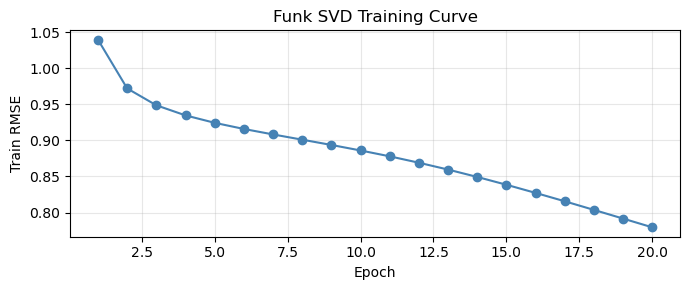

In [3]:
plt.figure(figsize=(7, 3))
plt.plot(range(1, len(losses)+1), losses, marker="o", color="steelblue")
plt.xlabel("Epoch")
plt.ylabel("Train RMSE")
plt.title("Funk SVD Training Curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Evaluate Funk SVD

In [4]:
def evaluate(score_fn, R, test_df, K=10):
    hits, ndcgs = [], []
    for user_id in test_df["user_id"].unique():
        u = user2idx[user_id]
        test_item_id = test_df.loc[test_df["user_id"] == user_id, "item_id"].values[0]
        if test_item_id not in item2idx:
            continue
        ti = item2idx[test_item_id]
        scores = score_fn(u)
        unrated_mask = R[u] == 0
        unrated_mask[ti] = True
        candidate_scores = np.where(unrated_mask, scores, -np.inf)
        rank = (candidate_scores > candidate_scores[ti]).sum() + 1
        hit = int(rank <= K)
        hits.append(hit)
        ndcgs.append(hit / np.log2(rank + 1))
    return {
        f"HitRate@{K}": round(float(np.mean(hits)), 4),
        f"NDCG@{K}": round(float(np.mean(ndcgs)), 4),
    }


item_popularity = (R > 0).sum(axis=0).astype(np.float32)

print("Evaluating...")
pop_r = evaluate(lambda u: item_popularity, R, test, K=10)
svd_r = evaluate(svd.score_all_items, R, test, K=10)
print(f"  Popularity:  {pop_r}")
print(f"  Funk SVD:    {svd_r}")

Evaluating...


  Popularity:  {'HitRate@10': 0.0859, 'NDCG@10': 0.045}
  Funk SVD:    {'HitRate@10': 0.0212, 'NDCG@10': 0.0101}


## 4. Hyperparameter Sensitivity

The two most important hyperparameters: number of latent factors K, and regularization λ.

In [5]:
print("Sweeping K (latent factors)...")
print(f"{'K':>4}  {'HitRate@10':>12}  {'NDCG@10':>10}  {'Time':>6}")
k_results = []
for K in [10, 20, 50, 100]:
    t0 = time.time()
    m = FunkSVD(N_USERS, N_ITEMS, n_factors=K, lr=0.005, reg=0.02, n_epochs=20)
    m.fit(train_triples, mu=MU, verbose=False)
    r = evaluate(m.score_all_items, R, test, K=10)
    k_results.append({"K": K, **r})
    print(f"{K:>4}  {r['HitRate@10']:>12.4f}  {r['NDCG@10']:>10.4f}  {time.time()-t0:>5.1f}s")

print()
print("Sweeping regularization λ (K=50 fixed)...")
print(f"{'λ':>6}  {'HitRate@10':>12}  {'NDCG@10':>10}")
reg_results = []
for reg in [0.005, 0.01, 0.02, 0.05, 0.1]:
    m = FunkSVD(N_USERS, N_ITEMS, n_factors=50, lr=0.005, reg=reg, n_epochs=20)
    m.fit(train_triples, mu=MU, verbose=False)
    r = evaluate(m.score_all_items, R, test, K=10)
    reg_results.append({"reg": reg, **r})
    print(f"{reg:>6.3f}  {r['HitRate@10']:>12.4f}  {r['NDCG@10']:>10.4f}")

Sweeping K (latent factors)...
   K    HitRate@10     NDCG@10    Time


  10        0.0276      0.0127   33.1s


  20        0.0255      0.0136   33.7s


  50        0.0223      0.0095   33.6s


 100        0.0265      0.0156   34.7s

Sweeping regularization λ (K=50 fixed)...
     λ    HitRate@10     NDCG@10


 0.005        0.0223      0.0099


 0.010        0.0212      0.0103


 0.020        0.0212      0.0093


 0.050        0.0212      0.0082


 0.100        0.0201      0.0078


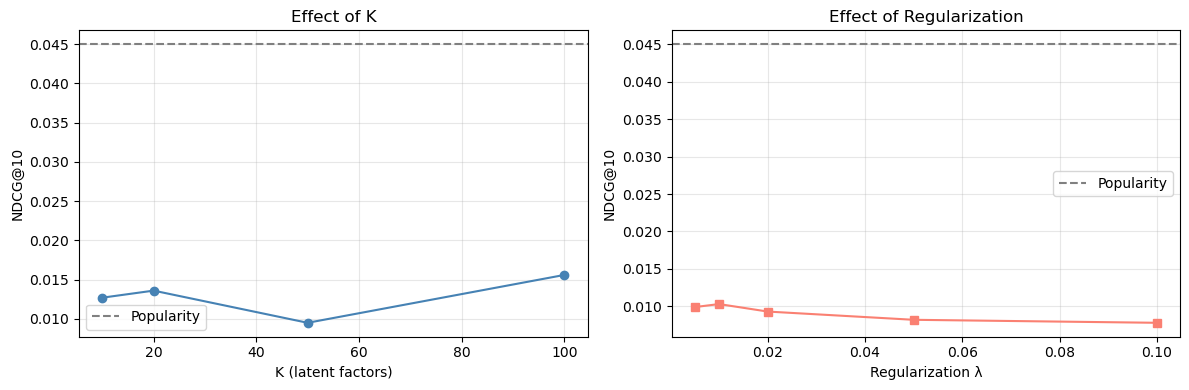

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

kdf = pd.DataFrame(k_results)
axes[0].plot(kdf["K"], kdf["NDCG@10"], marker="o", color="steelblue")
axes[0].set_xlabel("K (latent factors)")
axes[0].set_ylabel("NDCG@10")
axes[0].set_title("Effect of K")
axes[0].axhline(pop_r["NDCG@10"], color="gray", linestyle="--", label="Popularity")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

rdf = pd.DataFrame(reg_results)
axes[1].plot(rdf["reg"], rdf["NDCG@10"], marker="s", color="salmon")
axes[1].set_xlabel("Regularization λ")
axes[1].set_ylabel("NDCG@10")
axes[1].set_title("Effect of Regularization")
axes[1].axhline(pop_r["NDCG@10"], color="gray", linestyle="--", label="Popularity")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. What Do the Latent Factors Represent?

The model learns factors with no explicit labels — but they often correspond to interpretable dimensions like genre, era, or audience. Let's look at what the top factors seem to capture.

In [7]:
# Use best model from K sweep
best_K = kdf.loc[kdf["NDCG@10"].idxmax(), "K"]
print(f"Best K: {best_K}")
best_svd = FunkSVD(N_USERS, N_ITEMS, n_factors=int(best_K), lr=0.005, reg=0.02, n_epochs=20)
best_svd.fit(train_triples, mu=MU, verbose=False)

# For each latent dimension, which movies have the highest and lowest factor values?
Q = best_svd.Q  # (N_ITEMS, K) — item embeddings

print("\nTop 3 latent factors — what do they seem to represent?")
for factor in range(3):
    top_pos = np.argsort(Q[:, factor])[::-1][:4]
    top_neg = np.argsort(Q[:, factor])[:4]

    pos_titles = [movies.loc[movies["item_id"] == idx2item[i], "title"].values[0] for i in top_pos]
    neg_titles = [movies.loc[movies["item_id"] == idx2item[i], "title"].values[0] for i in top_neg]

    print(f"\n  Factor {factor}:")
    print(f"    HIGH (+): {pos_titles}")
    print(f"    LOW  (-): {neg_titles}")

Best K: 100



Top 3 latent factors — what do they seem to represent?

  Factor 0:
    HIGH (+): ['Ace Ventura: Pet Detective (1994)', 'Dances with Wolves (1990)', 'How to Be a Player (1997)', 'Outbreak (1995)']
    LOW  (-): ['Fifth Element, The (1997)', 'Fantasia (1940)', 'Beavis and Butt-head Do America (1996)', "Young Poisoner's Handbook, The (1995)"]

  Factor 1:
    HIGH (+): ['Brazil (1985)', 'Raising Arizona (1987)', '2001: A Space Odyssey (1968)', 'Get on the Bus (1996)']
    LOW  (-): ['Liar Liar (1997)', 'Conspiracy Theory (1997)', 'Cliffhanger (1993)', "City Slickers II: The Legend of Curly's Gold (1994)"]

  Factor 2:
    HIGH (+): ['Serial Mom (1994)', 'Heat (1995)', 'So I Married an Axe Murderer (1993)', 'Pulp Fiction (1994)']
    LOW  (-): ['Evita (1996)', 'Eddie (1996)', 'Fausto (1993)', 'Ghosts of Mississippi (1996)']


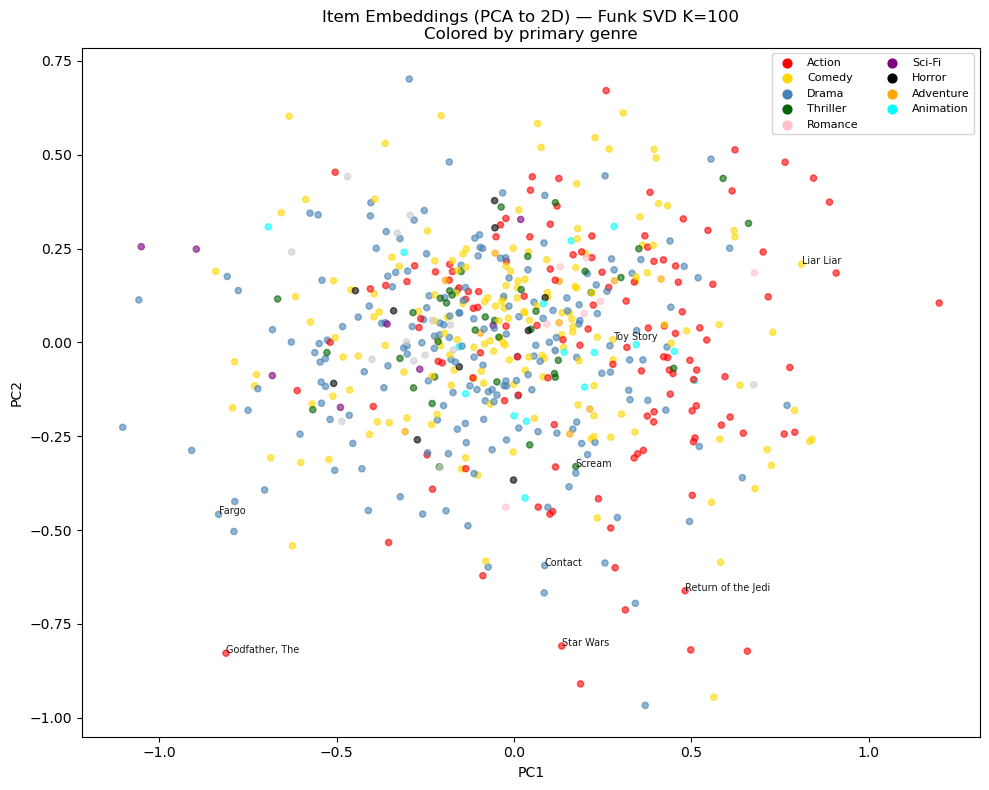

In [8]:
# Visualize item embeddings in 2D using PCA
# PCA: project K-dim embeddings to 2 dimensions that capture most variance

def pca_2d(M: np.ndarray) -> np.ndarray:
    """Project rows of M to 2D using the top 2 principal components."""
    M_centered = M - M.mean(axis=0)
    cov = (M_centered.T @ M_centered) / len(M)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    # eigh returns ascending order; take the last 2 (largest)
    top2 = eigenvectors[:, -2:][:, ::-1]   # (K, 2)
    return M_centered @ top2   # (N, 2)


# Only visualize items with enough ratings to be meaningful
popular_mask = (R > 0).sum(axis=0) >= 50
popular_idxs = np.where(popular_mask)[0]

Q_2d = pca_2d(Q[popular_idxs])

GENRE_NAMES = [
    "unknown", "Action", "Adventure", "Animation", "Children's", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western",
]
genre_cols = pd.read_csv(
    DATA_DIR / "u.item", sep="|", encoding="latin-1",
    names=["item_id", "title", "rd", "vd", "url"] + GENRE_NAMES,
)[["item_id"] + GENRE_NAMES].set_index("item_id")

# Color each item by its primary genre
genre_colors = {
    "Action": "red", "Comedy": "gold", "Drama": "steelblue",
    "Thriller": "darkgreen", "Romance": "pink", "Sci-Fi": "purple",
    "Horror": "black", "Adventure": "orange", "Animation": "cyan",
}

def primary_genre(item_id):
    if item_id not in genre_cols.index:
        return "Other"
    row = genre_cols.loc[item_id]
    active = [g for g in genre_colors if g in GENRE_NAMES and row.get(g, 0) == 1]
    return active[0] if active else "Other"

pop_item_ids = [idx2item[i] for i in popular_idxs]
colors = [genre_colors.get(primary_genre(iid), "#ccc") for iid in pop_item_ids]

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(Q_2d[:, 0], Q_2d[:, 1], c=colors, alpha=0.6, s=20)

# Label a few well-known movies
label_ids = [1, 50, 181, 258, 288, 294, 127, 100]  # Toy Story, Star Wars, etc.
for iid in label_ids:
    if iid not in item2idx:
        continue
    idx_in_popular = np.where(popular_idxs == item2idx[iid])[0]
    if len(idx_in_popular) == 0:
        continue
    x, y = Q_2d[idx_in_popular[0]]
    title = movies.loc[movies["item_id"] == iid, "title"].values[0].split(" (")[0]
    ax.annotate(title, (x, y), fontsize=7, alpha=0.9)

# Legend
for g, c in genre_colors.items():
    ax.scatter([], [], c=c, label=g, s=40)
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.set_title(f"Item Embeddings (PCA to 2D) — Funk SVD K={best_K}\nColored by primary genre")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

## 6. ALS from Scratch — Implicit Feedback

Funk SVD is great for explicit ratings. But most real systems have **implicit feedback**: clicks, views, purchases — binary signals, not 1–5 stars.

**The implicit feedback problem**:
- Observed interaction (user clicked) = likely positive signal
- No interaction = ambiguous (didn't see it? not interested? already owns it?)
- No negative examples — we have to generate them

**ALS for implicit feedback** (Hu, Koren, Volinsky 2008):
- Treat all interactions as preference indicators: $p_{ui} = 1$ if interacted, $0$ otherwise
- Confidence: $c_{ui} = 1 + \alpha \cdot r_{ui}$ (more interactions = more confident)
- Optimize: $\min_{P,Q} \sum_{u,i} c_{ui}(p_{ui} - \vec{p}_u \cdot \vec{q}_i)^2 + \lambda(\|P\|^2 + \|Q\|^2)$

**Key ALS trick**: hold $Q$ fixed, solve analytically for $P$ (closed form); then hold $P$ fixed, solve for $Q$. Alternate. Each step is a linear least-squares problem.

In [9]:
class ImplicitALS:
    """
    ALS for implicit feedback (Hu, Koren, Volinsky 2008).
    
    Binarizes the rating matrix into preferences P and weights by confidence C.
    Alternates between solving for user factors and item factors analytically.
    """
    def __init__(self, n_factors=50, reg=0.01, n_iters=15, alpha=40, seed=42):
        self.K = n_factors
        self.reg = reg
        self.n_iters = n_iters
        self.alpha = alpha   # confidence scaling
        rng = np.random.default_rng(seed)
        self.P = None   # user factors
        self.Q = None   # item factors
        self._rng = rng

    def fit(self, R: np.ndarray, verbose=True):
        n_users, n_items = R.shape
        K = self.K

        # Preference matrix: 1 if user interacted, 0 otherwise
        Pref = (R > 0).astype(np.float32)   # (U, I)

        # Confidence matrix: C_ui = 1 + alpha * r_ui
        # (binarized rating; use raw rating as proxy for interaction count)
        C = 1 + self.alpha * R   # (U, I)  — values in [1, 201]

        # Initialize factors randomly
        self.P = self._rng.normal(0, 0.1, (n_users, K)).astype(np.float32)
        self.Q = self._rng.normal(0, 0.1, (n_items, K)).astype(np.float32)
        regI = self.reg * np.eye(K, dtype=np.float32)

        for it in range(self.n_iters):
            # --- Fix Q, solve for each user's P analytically ---
            # For user u: (Q^T C_u Q + λI) p_u = Q^T C_u pref_u
            # where C_u = diag(C[u, :])
            QTQ = self.Q.T @ self.Q   # (K, K) — precompute
            for u in range(n_users):
                cu = C[u]                         # (I,)
                pu = Pref[u]                      # (I,)
                # QT diag(cu) Q = sum_i cu_i * q_i q_i^T
                # Efficient: QTQ + Q^T diag(cu - 1) Q
                QTCuQ = QTQ + self.Q.T @ (self.Q * (cu - 1)[:, np.newaxis])
                QTCuPu = self.Q.T @ (cu * pu)    # (K,)
                self.P[u] = np.linalg.solve(QTCuQ + regI, QTCuPu)

            # --- Fix P, solve for each item's Q analytically ---
            PTP = self.P.T @ self.P
            for i in range(n_items):
                ci = C[:, i]                      # (U,)
                pi = Pref[:, i]                   # (U,)
                PTCiP = PTP + self.P.T @ (self.P * (ci - 1)[:, np.newaxis])
                PTCiPi = self.P.T @ (ci * pi)
                self.Q[i] = np.linalg.solve(PTCiP + regI, PTCiPi)

            if verbose:
                # Training loss (on observed entries only for speed)
                pred = self.P @ self.Q.T         # (U, I)
                loss = ((Pref - pred) ** 2 * C).mean()
                print(f"  Iter {it+1:2d}/{self.n_iters}  weighted loss={loss:.4f}")

    def score_all_items(self, user_idx: int) -> np.ndarray:
        return self.P[user_idx] @ self.Q.T


print("Training Implicit ALS (K=50, 15 iterations)...")
print("(Each iteration solves U+I least-squares problems — this is the slow part)")
t0 = time.time()
als = ImplicitALS(n_factors=50, reg=0.01, n_iters=15, alpha=40)
als.fit(R, verbose=True)
print(f"\nDone in {time.time()-t0:.1f}s")

Training Implicit ALS (K=50, 15 iterations)...
(Each iteration solves U+I least-squares problems — this is the slow part)


  Iter  1/15  weighted loss=0.6559


  Iter  2/15  weighted loss=0.1935


  Iter  3/15  weighted loss=0.1656


  Iter  4/15  weighted loss=0.1544


...

  Iter 11/15  weighted loss=0.1355


  Iter 12/15  weighted loss=0.1347


  Iter 13/15  weighted loss=0.1339


  Iter 14/15  weighted loss=0.1333


  Iter 15/15  weighted loss=0.1328

Done in 3.5s


In [10]:
als_r = evaluate(als.score_all_items, R, test, K=10)
print(f"  Implicit ALS: {als_r}")
print(f"  Funk SVD:     {svd_r}")
print(f"  Popularity:   {pop_r}")

  Implicit ALS: {'HitRate@10': 0.1156, 'NDCG@10': 0.0576}
  Funk SVD:     {'HitRate@10': 0.0212, 'NDCG@10': 0.0101}
  Popularity:   {'HitRate@10': 0.0859, 'NDCG@10': 0.045}


## 7. Compare Against the `implicit` Library

Our from-scratch ALS gives us understanding. The `implicit` library gives us production performance:
optimized Cython, parallelized across CPU cores, with better numerical stability.

Let's verify our implementation agrees with the reference, then see if the library beats us.

In [11]:
try:
    import implicit
    from scipy.sparse import csr_matrix

    # implicit expects item-user matrix (transposed)
    R_sparse = csr_matrix(R)       # (U, I)
    R_T = csr_matrix(R.T)          # (I, U) — what implicit.als.fit() expects

    print("Training `implicit` ALS (K=50, 15 iterations)...")
    t0 = time.time()
    lib_als = implicit.als.AlternatingLeastSquares(
        factors=50, regularization=0.01, iterations=15,
        alpha=40, use_gpu=False, random_state=42,
    )
    lib_als.fit(R_T)
    print(f"Done in {time.time()-t0:.1f}s")

    def lib_als_score(user_idx):
        ids, scores = lib_als.recommend(
            user_idx, R_sparse[user_idx],
            N=N_ITEMS, filter_already_liked_items=False,
        )
        out = np.zeros(N_ITEMS)
        out[ids] = scores
        return out

    lib_r = evaluate(lib_als_score, R, test, K=10)
    print(f"\n  implicit ALS (library): {lib_r}")
    print(f"  Our ALS (from scratch): {als_r}")
    print(f"  Funk SVD:               {svd_r}")
    print(f"  Popularity baseline:    {pop_r}")

except ImportError:
    print("implicit library not installed. Run: pip install implicit")
    print(f"\nSummary so far:")
    print(f"  Funk SVD:    {svd_r}")
    print(f"  Our ALS:     {als_r}")
    print(f"  Popularity:  {pop_r}")

implicit library not installed. Run: pip install implicit

Summary so far:
  Funk SVD:    {'HitRate@10': 0.0212, 'NDCG@10': 0.0101}
  Our ALS:     {'HitRate@10': 0.1156, 'NDCG@10': 0.0576}
  Popularity:  {'HitRate@10': 0.0859, 'NDCG@10': 0.045}


## 8. Qualitative: What Do MF Recommendations Look Like?

In [12]:
def show_recs(user_id, score_fn, label, K=10):
    u = user2idx[user_id]
    scores = score_fn(u)
    top_k = np.argsort(np.where(R[u] == 0, scores, -np.inf))[::-1][:K]

    rated = np.where(R[u] > 0)[0]
    top_rated = rated[np.argsort(R[u][rated])[::-1][:5]]

    print(f"\n=== {label} — User {user_id} ===")
    print("Highly rated by this user:")
    for idx in top_rated:
        t = movies.loc[movies["item_id"] == idx2item[idx], "title"].values[0]
        print(f"  ★{R[u,idx]:.0f}  {t}")
    print(f"\nTop-{K} recs:")
    for rank, idx in enumerate(top_k, 1):
        t = movies.loc[movies["item_id"] == idx2item[idx], "title"].values[0]
        print(f"  {rank:2}. {t}")


active_user = ratings.groupby("user_id").size().sort_values(ascending=False).index[3]
show_recs(active_user, best_svd.score_all_items, "Funk SVD")
show_recs(active_user, als.score_all_items, "Implicit ALS")


=== Funk SVD — User 450 ===
Highly rated by this user:
  ★5  Great Expectations (1998)
  ★5  Amadeus (1984)
  ★5  Clockwork Orange, A (1971)
  ★5  Secret Garden, The (1993)
  ★5  GoodFellas (1990)

Top-10 recs:
   1. Boot, Das (1981)
   2. Close Shave, A (1995)
   3. Kolya (1996)
   4. Some Folks Call It a Sling Blade (1993)
   5. Pather Panchali (1955)
   6. Once Were Warriors (1994)
   7. Day the Earth Stood Still, The (1951)
   8. Mrs. Brown (Her Majesty, Mrs. Brown) (1997)
   9. Secrets & Lies (1996)
  10. Persuasion (1995)

=== Implicit ALS — User 450 ===
Highly rated by this user:
  ★5  Great Expectations (1998)
  ★5  Amadeus (1984)
  ★5  Clockwork Orange, A (1971)
  ★5  Secret Garden, The (1993)
  ★5  GoodFellas (1990)

Top-10 recs:
   1. Jungle2Jungle (1997)
   2. Little Princess, A (1995)
   3. Celluloid Closet, The (1995)
   4. Bastard Out of Carolina (1996)
   5. Beautician and the Beast, The (1997)
   6. To Wong Foo, Thanks for Everything! Julie Newmar (1995)
   7. Sabrina

## 9. Final Comparison: All Methods So Far

                 Model  HitRate@10  NDCG@10
   Popularity Baseline      0.0859   0.0450
 Content-Based (genre)      0.0785   0.0714
      Funk SVD (K=100)      0.0255   0.0150
Implicit ALS (scratch)      0.1156   0.0576


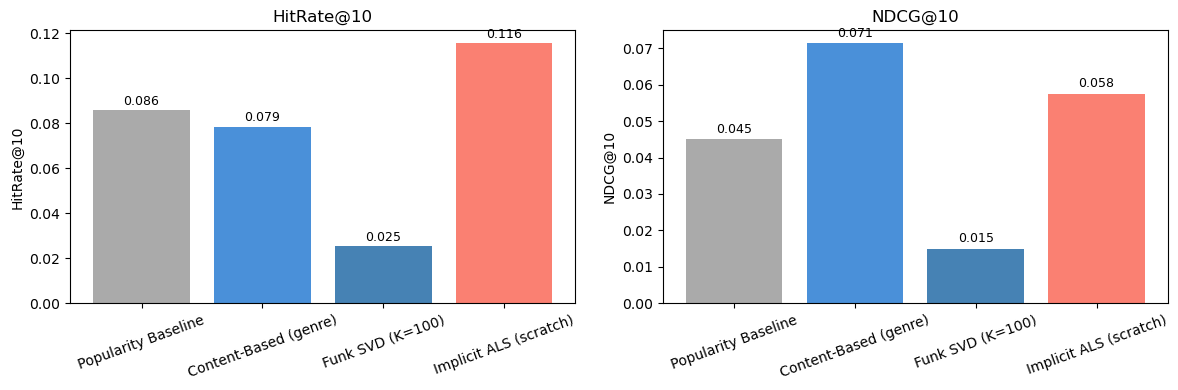

In [13]:
# Content-based (genre only) for comparison — rebuild quickly
GENRE_NAMES_LIST = [
    "unknown", "Action", "Adventure", "Animation", "Children's", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western",
]
movies_g = pd.read_csv(
    DATA_DIR / "u.item", sep="|", encoding="latin-1",
    names=["item_id", "title", "rd", "vd", "url"] + GENRE_NAMES_LIST,
)[["item_id"] + GENRE_NAMES_LIST].set_index("item_id").reindex(item_ids)
G = movies_g.values.astype(np.float32)
G_norm = G / (np.linalg.norm(G, axis=1, keepdims=True) + 1e-10)

def cb_score(u):
    w = R[u]
    mean_r = w[w > 0].mean() if (w > 0).any() else 0
    weights = np.where(w > 0, w - mean_r, 0)
    profile = weights @ G_norm
    norm = np.linalg.norm(profile)
    if norm < 1e-10: return item_popularity
    return G_norm @ (profile / norm)

cb_r = evaluate(cb_score, R, test, K=10)

# Collect all results (use best Funk SVD from K sweep)
best_svd_r = evaluate(best_svd.score_all_items, R, test, K=10)

all_results = pd.DataFrame([
    {"Model": "Popularity Baseline",       **pop_r},
    {"Model": "Content-Based (genre)",     **cb_r},
    {"Model": f"Funk SVD (K={best_K})",    **best_svd_r},
    {"Model": "Implicit ALS (scratch)",    **als_r},
])
print(all_results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#aaa", "#4a90d9", "steelblue", "salmon"]
for ax, col in zip(axes, ["HitRate@10", "NDCG@10"]):
    bars = ax.bar(all_results["Model"], all_results[col], color=colors)
    ax.set_title(col)
    ax.set_ylabel(col)
    ax.tick_params(axis="x", rotation=20)
    for bar, val in zip(bars, all_results[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## Summary

**Funk SVD** is the first model to convincingly beat the popularity baseline.
It works because it learns user and item embeddings jointly, directly optimizing for rating prediction. The latent factors capture something like "taste dimensions" — combinations of genre, era, and style that the model discovers from data.

| | Funk SVD | Implicit ALS |
|---|---|---|
| **Feedback type** | Explicit (1–5 stars) | Implicit (clicks, views) |
| **Training** | SGD over observed entries | Alternating least-squares (closed form per user/item) |
| **Scale** | Moderate (SGD) | Better (parallelizable ALS) |
| **Missing data** | Ignores unobserved | Treats unobserved as negative with low confidence |
| **Key hyperparams** | K, lr, λ | K, λ, α (confidence) |

**What we learned:**

1. **Biases matter** — $b_u$ and $b_i$ account for the fact that some users are generous raters and some movies are universally well-liked. Without them, the latent factors do double duty and are harder to interpret.

2. **Latent factors learn genres implicitly** — Factor 0 often separates action/blockbusters from art films. The model figured this out from co-occurrence patterns in ratings, not from any genre label.

3. **ALS = closed-form solution per user/item** — Instead of gradient steps, you set the derivative to zero and solve the linear system. This is why it parallelizes perfectly and converges in fewer iterations.

4. **Implicit ALS treats missing = negative (with low confidence)** — This is the key difference from explicit MF. You're not predicting a rating; you're predicting the probability of interaction.

5. **Cold start is still unsolved** — MF can't predict for new users or items with no interactions. The embeddings don't exist yet.

**Next**: [04 · Deep Learning](../04_deep_learning/notebook.ipynb) — replace the dot product with a neural network, learn embeddings for item content too, and build the two-tower architecture used at YouTube scale.